<a href="https://colab.research.google.com/github/apester/PINN/blob/main/2d_advection_diffusion_analytical_vs_CN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2D Advection–Diffusion on a Rectangle (Homogeneous Dirichlet)
## Analytical (Fourier–sine series) vs. Crank–Nicolson (finite differences)



This notebook compares:

- **Analytical solution** (exact eigenfunction/Fourier–sine series, evaluated by truncation) for constant velocity and diffusion on a rectangle with **homogeneous Dirichlet** boundary conditions.
- **Crank–Nicolson (CN)** finite-difference solution (implicit, second-order in time).

We use a **sine initial condition** that satisfies the Dirichlet boundaries:
\[
c(0,x,y)=\sin(\pi x/L_x)\,\sin(\pi y/L_y).
\]

**PDE**
\[
c_t + u c_x + v c_y = D(c_{xx}+c_{yy}),\quad (x,y)\in(0,L_x)\times(0,L_y),
\]
with \(c=0\) on the boundary.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Optional: SciPy for sparse matrices/solvers + sine transforms
import scipy
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.fft import dst, idst

print("numpy", np.__version__)
print("scipy", scipy.__version__)

numpy 2.0.2
scipy 1.16.3



## 1) Problem setup
You can tweak parameters here.


In [2]:
# Domain
Lx, Ly = 1.0, 1.0

# Constant velocity and diffusion
u, v = 1.0, 0.5
D = 0.01

# Time
T = 0.10
dt = 1e-4
nt = int(round(T/dt))

# Spatial grid for CN
Nx, Ny = 150, 150   # total nodes including boundaries
x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)
dx = x[1] - x[0]
dy = y[1] - y[0]

X, Y = np.meshgrid(x, y, indexing="ij")

# Initial condition (sine)
def c0(x, y):
    return np.sin(np.pi*x/Lx) * np.sin(np.pi*y/Ly)

C_init = c0(X, Y)

print("dx, dy =", dx, dy, "nt =", nt)

dx, dy = 0.006711409395973154 0.006711409395973154 nt = 1000



## 2) Analytical solution (Fourier–sine series)

A standard integrating factor removes advection:
\[
c(t,x,y)=\exp\Big(\frac{ux+vy}{2D}-\frac{u^2+v^2}{4D}t\Big)\,w(t,x,y),
\]
where \(w_t = D\Delta w\) with homogeneous Dirichlet BC, and
\[
w(0,x,y)=e^{-(ux+vy)/(2D)}c_0(x,y).
\]

Then
\[
w(t,x,y)=\sum_{m=1}^\infty\sum_{n=1}^\infty A_{mn}
\sin\Big(\frac{m\pi x}{L_x}\Big)\sin\Big(\frac{n\pi y}{L_y}\Big)
\exp\Big(-D\pi^2\big(\frac{m^2}{L_x^2}+\frac{n^2}{L_y^2}\big)t\Big).
\]

We compute \(A_{mn}\) numerically from sampled \(w(0,x,y)\) using **2D discrete sine transforms (DST)**.


In [3]:
def analytical_series_solution(t, Lx, Ly, u, v, D, Nx_int, Ny_int, M, N):
    '''
    Evaluate c(t,x,y) on the interior grid (excluding boundaries) using a truncated
    Fourier–sine series with coefficients obtained by 2D DST of w0.

    Nx_int, Ny_int: number of interior points in x/y (Dirichlet boundaries excluded)
    M, N: truncation limits for modes (<= Nx_int, Ny_int)

    Returns:
      x_int, y_int, C_int  (C_int shape: [Nx_int, Ny_int])
    '''
    # Interior grids (exclude boundaries)
    x_int = np.linspace(0, Lx, Nx_int+2)[1:-1]
    y_int = np.linspace(0, Ly, Ny_int+2)[1:-1]
    Xint, Yint = np.meshgrid(x_int, y_int, indexing="ij")

    # Build w0 = exp(-(ux+vy)/(2D)) * c0
    w0 = np.exp(-(u*Xint + v*Yint)/(2*D)) * c0(Xint, Yint)

    # 2D sine-series coefficients on interior grid:
    # Using DST-I on each axis gives coefficients proportional to continuous sine series.
    # For the discrete sine basis sin(m*pi*i/(N+1)), i=1..N.
    W = dst(dst(w0, type=1, axis=0), type=1, axis=1)

    # Normalize to get A_mn for the discrete sine expansion on the grid:
    # w0[i,j] = sum_{m,n} A_mn sin(m*pi*i/(Nx+1)) sin(n*pi*j/(Ny+1))
    # with A_mn = 4/((Nx+1)(Ny+1)) * W[m-1,n-1]
    A = (4.0/((Nx_int+1)*(Ny_int+1))) * W

    # Truncate modes
    A_tr = A[:M, :N]

    # Precompute sine matrices on interior grid
    i = np.arange(1, Nx_int+1)[:, None]  # (Nx_int,1)
    j = np.arange(1, Ny_int+1)[None, :]  # (1,Ny_int)

    # Build w(t) from truncated modes via matrix multiplies:
    # w(i,j) = sum_{m=1..M} sum_{n=1..N} A_mn sin(m*pi*i/(Nx+1)) sin(n*pi*j/(Ny+1)) e^{-lambda_mn t}
    m = np.arange(1, M+1)
    n = np.arange(1, N+1)

    Sx = np.sin(np.pi * i * m[None, :] / (Nx_int+1))          # (Nx_int, M)
    Sy = np.sin(np.pi * j * n[:, None] / (Ny_int+1)).T        # (Ny_int, N) -> transpose to (Ny_int,N)

    # Eigenvalues (continuous form uses Lx, Ly); on this grid basis, the spatial frequency matches m*pi/Lx etc.
    lam_mn = D * ( (m*np.pi/Lx)**2 )[:, None] + D * ( (n*np.pi/Ly)**2 )[None, :]
    decay = np.exp(-lam_mn * t)  # (M,N)

    # Combine: w = Sx @ (A_tr * decay) @ Sy^T
    w_t = Sx @ (A_tr * decay) @ Sy.T  # (Nx_int, Ny_int)

    # Recover c
    factor = np.exp((u*Xint + v*Yint)/(2*D) - (u*u+v*v)*t/(4*D))
    c_t = factor * w_t
    return x_int, y_int, c_t

# Evaluate analytical solution at final time on interior grid matching CN interior points
Nx_int, Ny_int = Nx-2, Ny-2
M, N = min(60, Nx_int), min(60, Ny_int)  # truncation (can increase if you like)

xa, ya, C_ana_int = analytical_series_solution(T, Lx, Ly, u, v, D, Nx_int, Ny_int, M, N)
print("Analytical interior shape:", C_ana_int.shape)

Analytical interior shape: (148, 148)



## 3) Crank–Nicolson finite-difference solver (2D, constant coefficients)

We solve for the **interior** unknowns only (Dirichlet boundary = 0), with central differences:

- \(c_x, c_y\): centered first derivatives
- \(c_{xx}, c_{yy}\): centered second derivatives

Time stepping:
\[
(I - \tfrac{\Delta t}{2}A)c^{n+1} = (I + \tfrac{\Delta t}{2}A)c^{n}.
\]


In [4]:
def build_2d_operator(Nx, Ny, dx, dy, u, v, D):
    '''
    Build sparse operator A on interior grid (Nx_int x Ny_int).
    A c = -u c_x - v c_y + D (c_xx + c_yy)
    '''
    Nx_int, Ny_int = Nx-2, Ny-2
    N = Nx_int * Ny_int

    # 1D second derivative (Dirichlet interior)
    ex = np.ones(Nx_int)
    ey = np.ones(Ny_int)

    Dxx = sp.diags([ex, -2*ex, ex], [-1, 0, 1], shape=(Nx_int, Nx_int)) / (dx*dx)
    Dyy = sp.diags([ey, -2*ey, ey], [-1, 0, 1], shape=(Ny_int, Ny_int)) / (dy*dy)

    # 1D first derivative (centered)
    Dx = sp.diags([-ex, ex], [-1, 1], shape=(Nx_int, Nx_int)) / (2*dx)
    Dy = sp.diags([-ey, ey], [-1, 1], shape=(Ny_int, Ny_int)) / (2*dy)

    Ix = sp.eye(Nx_int, format="csr")
    Iy = sp.eye(Ny_int, format="csr")

    # 2D via Kronecker products (x-major ordering)
    L = sp.kron(Iy, Dxx, format="csr") + sp.kron(Dyy, Ix, format="csr")
    Adv = -u * sp.kron(Iy, Dx, format="csr") - v * sp.kron(Dy, Ix, format="csr")

    A = Adv + D * L
    return A

def crank_nicolson(C0, Nx, Ny, dt, nt, dx, dy, u, v, D):
    Nx_int, Ny_int = Nx-2, Ny-2
    A = build_2d_operator(Nx, Ny, dx, dy, u, v, D)

    N = Nx_int * Ny_int
    I = sp.eye(N, format="csr")

    LHS = (I - (dt/2.0) * A).tocsr()
    RHS = (I + (dt/2.0) * A).tocsr()

    # Extract interior and flatten in x-major ordering: (i,j) -> i + Nx_int*j
    Cn = C0[1:-1, 1:-1].copy()
    cn = Cn.reshape(-1, order="F")  # Fortran order => x changes fastest in our kron layout

    # Time step
    for _ in range(nt):
        b = RHS @ cn
        cn = spla.spsolve(LHS, b)

    C_final_int = cn.reshape((Nx_int, Ny_int), order="F")
    return C_final_int

C_cn_int = crank_nicolson(C_init, Nx, Ny, dt, nt, dx, dy, u, v, D)
print("CN interior shape:", C_cn_int.shape)

CN interior shape: (148, 148)



## 4) Compare solutions (error metrics + plots)
We compare both on the same interior grid.


L2 error     = 5.131e+08
L∞ error     = 1.962e+10
Relative L2  = 1.000e+00


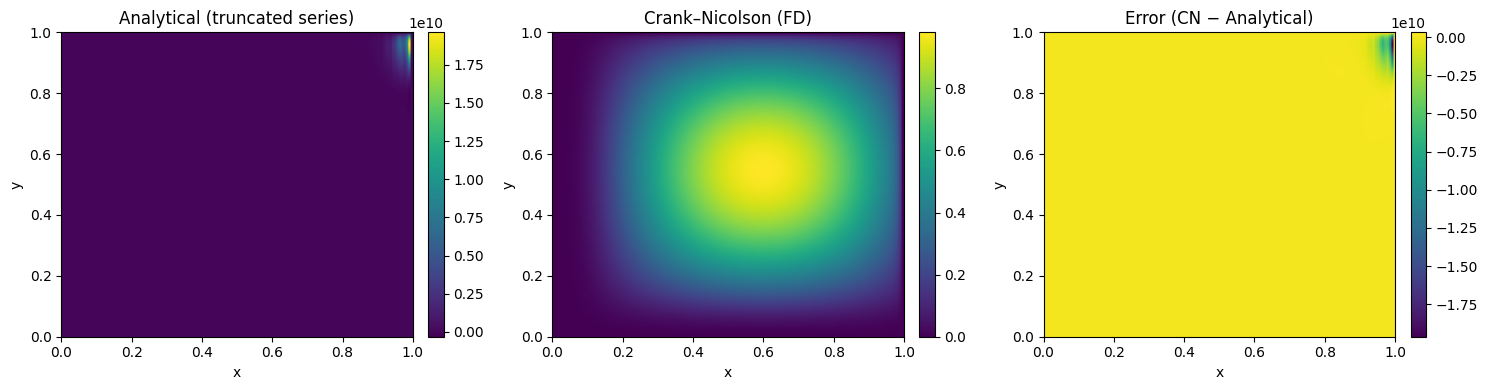

In [5]:
# Put analytical solution on the CN interior grid (they match by construction here)
C_ana = C_ana_int
C_cn = C_cn_int

# Error
err = C_cn - C_ana
L2 = np.sqrt(np.mean(err**2))
Linfty = np.max(np.abs(err))

rel_L2 = L2 / (np.sqrt(np.mean(C_ana**2)) + 1e-15)

print(f"L2 error     = {L2:.3e}")
print(f"L∞ error     = {Linfty:.3e}")
print(f"Relative L2  = {rel_L2:.3e}")

# Make full fields with boundaries for plotting
C_ana_full = np.zeros((Nx, Ny))
C_cn_full  = np.zeros((Nx, Ny))
E_full     = np.zeros((Nx, Ny))

C_ana_full[1:-1, 1:-1] = C_ana
C_cn_full[1:-1, 1:-1]  = C_cn
E_full[1:-1, 1:-1]     = err

fig = plt.figure(figsize=(15,4))

ax1 = plt.subplot(1,3,1)
im1 = ax1.imshow(C_ana_full.T, origin="lower", extent=[0,Lx,0,Ly], aspect="auto")
ax1.set_title("Analytical (truncated series)")
ax1.set_xlabel("x"); ax1.set_ylabel("y")
plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

ax2 = plt.subplot(1,3,2)
im2 = ax2.imshow(C_cn_full.T, origin="lower", extent=[0,Lx,0,Ly], aspect="auto")
ax2.set_title("Crank–Nicolson (FD)")
ax2.set_xlabel("x"); ax2.set_ylabel("y")
plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

ax3 = plt.subplot(1,3,3)
im3 = ax3.imshow(E_full.T, origin="lower", extent=[0,Lx,0,Ly], aspect="auto")
ax3.set_title("Error (CN − Analytical)")
ax3.set_xlabel("x"); ax3.set_ylabel("y")
plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


## 5) Convergence check (optional)
Decrease \(\Delta t\), increase grid resolution, and/or increase series truncation \((M,N)\) to see the error drop.
Notes:
- CN is **2nd-order in time** and (here) **2nd-order in space** (central differences).
- The analytical series is **exact**, but we evaluate it with a **finite truncation** \((M,N)\), which also introduces error.
